# Phase 1 Backtest Report 2 — ML vs. Baselines (Out-of-Sample)

**Question:** Does a machine-learning strategy beat a passive buy-and-hold benchmark, after transaction costs and slippage, on genuinely out-of-sample data?

**Setup.** Five strategies are compared on the same event-driven backtester, over the **last 20% of each ticker's history** (the held-out test window the ML model never trained on):

- **Buy & Hold** — passive, always long (the benchmark).
- **Momentum** — long/flat.
- **SMA 20/50 crossover** — long/flat.
- **12-1 Momentum** — long/flat.
- **Logistic (ML)** — logistic regression predicting next-day direction; **long/short** (see note below).

The ML model is a **simple logistic regression** trained on 8 price-derived features (returns, log returns, 20/60-day rolling volatility, 1/5/10-day lagged returns, RSI-14), pooled across all tickers, with a chronological 60/20/20 split and the scaler fit on training data only.

> **The point is not to make money.** An honest "ML did not beat buy-and-hold after costs" is a stronger, more credible result than a suspicious high number that secretly leaks data.

In [1]:
import sys
sys.path.append("src")

import pandas as pd
import matplotlib.pyplot as plt

from backtest import run_backtest, run_metrics
from load import show_ticker_list

tickers = show_ticker_list()
more_liquid = ["SPY", "QQQ", "AAPL", "MSFT", "NVDA"]

# label -> dispatch string used by run_backtest
strategies = {
    "Buy & Hold": "buy_and_hold",
    "Momentum": "momentum",
    "SMA 20/50": "sma",
    "12-1 Momentum": "12-1",
    "Logistic (ML)": "simple logistic",
}

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Run all strategies over the test window

`run_backtest` runs each strategy across the full history (so stateful strategies warm up) and returns the equity curve already sliced to the last 20% test window. `run_metrics` computes total return, annualized return, max drawdown, Sharpe, and Calmar on that slice.

In [2]:
curves = {}     # (ticker, label) -> (curve, dates)
records = []    # one row per (ticker, strategy)

for ticker in tickers:
    periods_per_year = 252 if ticker in more_liquid else 365
    for label, key in strategies.items():
        curve, dates = run_backtest(ticker, key)
        curves[(ticker, label)] = (curve, dates)
        m = run_metrics(curve, dates, periods_per_year)
        records.append({"ticker": ticker, "strategy": label, **m})

results = pd.DataFrame(records)
results.head()

c:\Users\steff\OneDrive\Desktop\ml-trading-project\ml-trading-project\src\backtest.py:109: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = (reward_average/v)*(math.sqrt(period_per_year))
c:\Users\steff\OneDrive\Desktop\ml-trading-project\ml-trading-project\src\backtest.py:113: RuntimeWarning: invalid value encountered in scalar divide
  calmar = annual_return/max_drawdown
c:\Users\steff\OneDrive\Desktop\ml-trading-project\ml-trading-project\src\backtest.py:109: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = (reward_average/v)*(math.sqrt(period_per_year))
c:\Users\steff\OneDrive\Desktop\ml-trading-project\ml-trading-project\src\backtest.py:113: RuntimeWarning: invalid value encountered in scalar divide
  calmar = annual_return/max_drawdown
c:\Users\steff\OneDrive\Desktop\ml-trading-project\ml-trading-project\src\backtest.py:109: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = (reward_average/v)*(math.sqrt(period_per_year

,ticker,strategy,total_return,annual_return,max_drawdown,sharpe,calmar
0,SPY,Buy & Hold,36.830342,16.949416,18.742977,1.012041,0.904308
1,SPY,Momentum,-5.676361,-2.875760,6.190134,-1.359037,-0.464571
2,SPY,SMA 20/50,3.596798,1.780052,1.869028,0.808015,0.952395
3,SPY,12-1 Momentum,6.146493,3.023217,3.896235,0.918401,0.775933
4,SPY,Logistic (ML),7.507149,3.680521,3.894520,1.110559,0.945051


## Comparison tables

Total return and Sharpe, per ticker, over the test window.

In [3]:
order = list(strategies.keys())

return_table = results.pivot(index="ticker", columns="strategy", values="total_return")[order].round(2)
sharpe_table = results.pivot(index="ticker", columns="strategy", values="sharpe")[order].round(2)
drawdown_table = results.pivot(index="ticker", columns="strategy", values="max_drawdown")[order].round(2)

print("Total Return (%) — test window")
display(return_table)

print("\nSharpe — test window")
display(sharpe_table)

print("\nMax Drawdown (%) — test window")
display(drawdown_table)

Total Return (%) — test window


strategy,Buy & Hold,Momentum,SMA 20/50,12-1 Momentum,Logistic (ML)
ticker,,,,,
AAPL,43.40,1.93,2.45,5.80,9.47
BTC-USD,-1.93,0.00,0.00,0.00,-1.47
ETH-USD,-31.32,-10.36,7.83,-0.80,1.07
MSFT,-10.25,-8.28,-3.10,-4.08,-0.56
NVDA,61.74,-8.87,3.16,14.36,32.73
QQQ,43.75,-8.03,4.33,6.86,9.55
SPY,36.83,-5.68,3.60,6.15,7.51



Sharpe — test window


strategy,Buy & Hold,Momentum,SMA 20/50,12-1 Momentum,Logistic (ML)
ticker,,,,,
AAPL,0.78,0.27,0.33,0.55,0.78
BTC-USD,0.21,NaN,NaN,NaN,-0.05
ETH-USD,0.05,-0.74,0.55,0.00,0.11
MSFT,-0.07,-1.07,-0.54,-0.50,-0.03
NVDA,0.75,-0.64,0.28,0.76,1.51
QQQ,0.93,-1.33,0.69,0.79,1.06
SPY,1.01,-1.36,0.81,0.92,1.11



Max Drawdown (%) — test window


strategy,Buy & Hold,Momentum,SMA 20/50,12-1 Momentum,Logistic (ML)
ticker,,,,,
AAPL,33.36,6.47,5.44,7.40,7.41
BTC-USD,53.06,0.00,0.00,0.00,10.13
ETH-USD,67.61,17.64,11.18,15.19,22.34
MSFT,34.49,8.51,4.89,7.53,7.70
NVDA,36.88,14.17,6.02,7.80,4.89
QQQ,22.76,9.42,2.49,4.84,4.83
SPY,18.74,6.19,1.87,3.90,3.89


## Equity curves (test window)

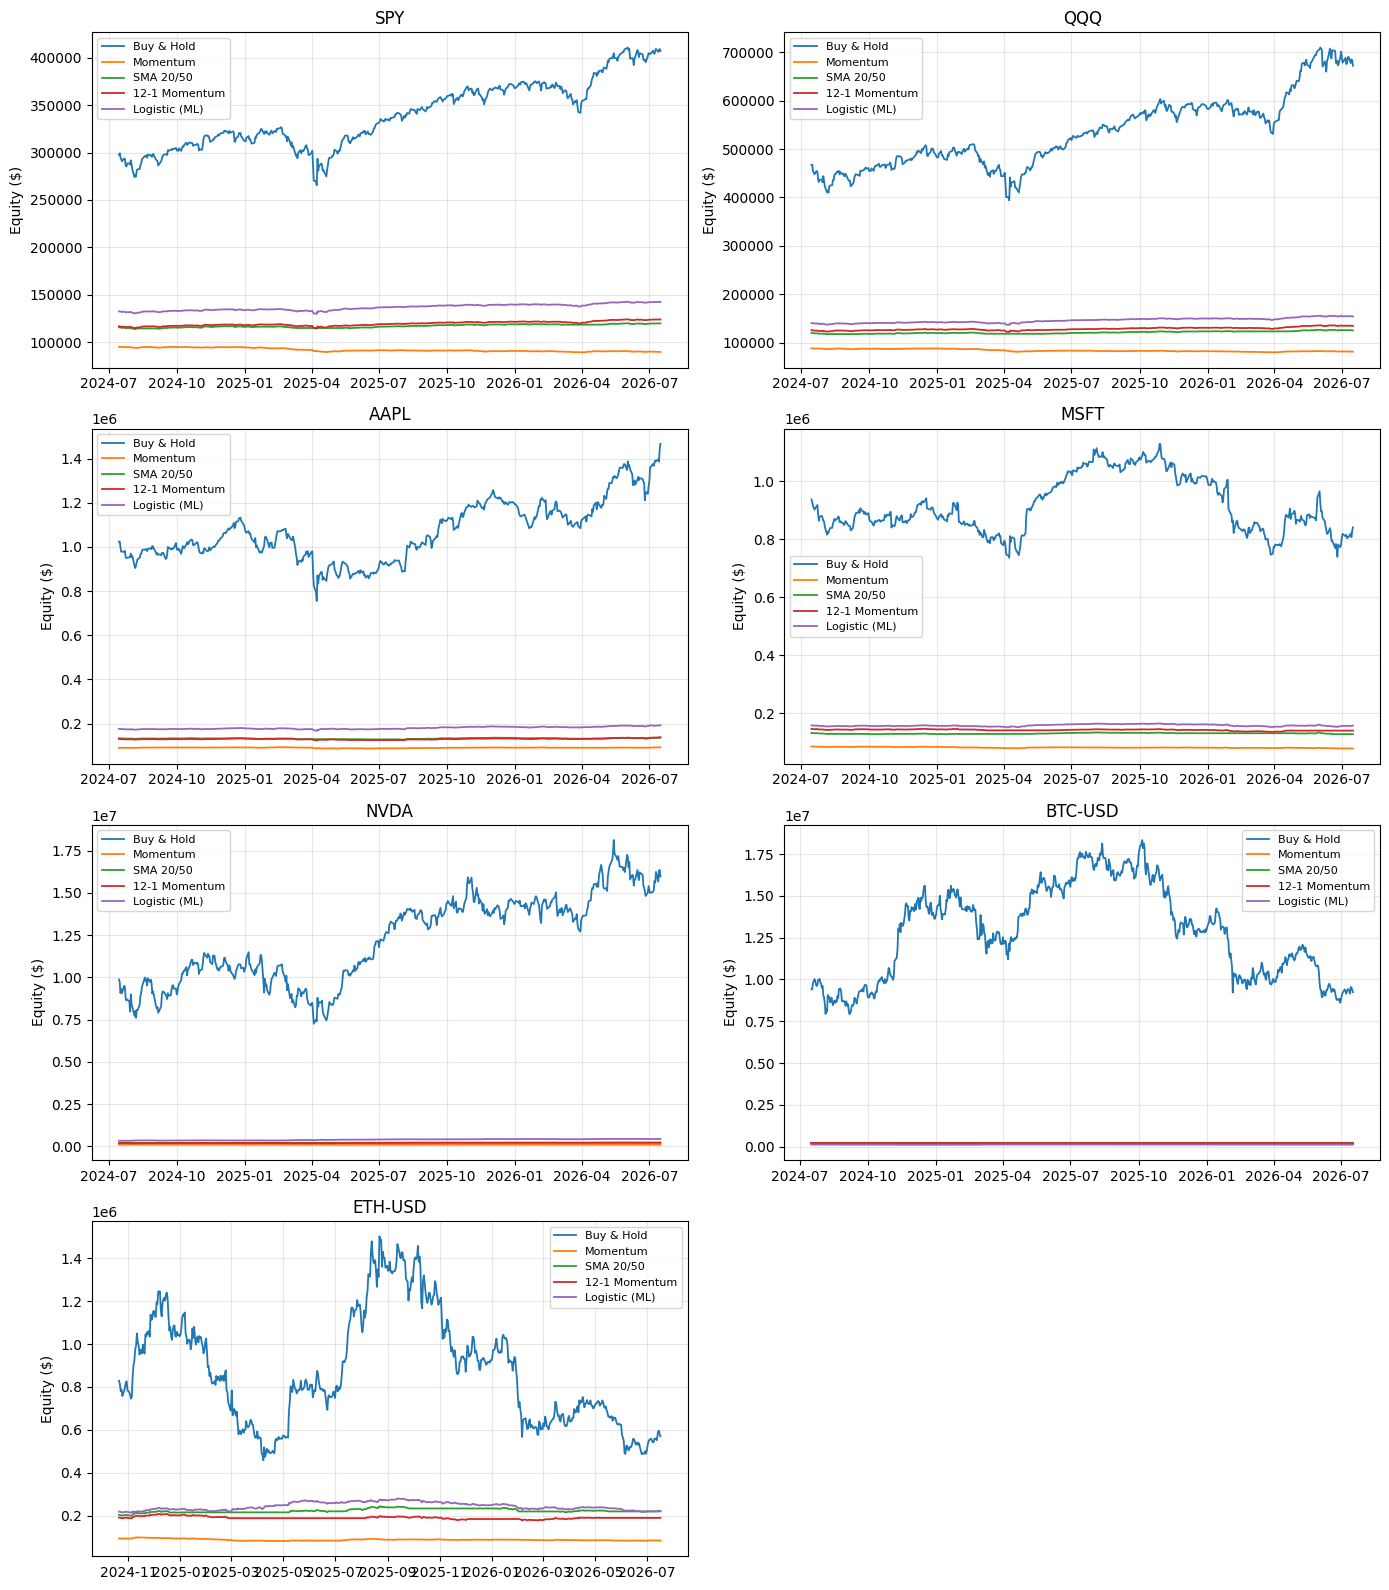

In [4]:
n = len(tickers)
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
axes = axes.flatten()

for ax, ticker in zip(axes, tickers):
    for label in order:
        curve, dates = curves[(ticker, label)]
        ax.plot(dates, curve, label=label, linewidth=1.3)
    ax.set_title(ticker)
    ax.set_ylabel("Equity ($)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Findings

### 1. On returns, the ML strategy does **not** beat buy-and-hold

Across the test window, the logistic strategy earns a **fraction** of buy-and-hold's return on the bull names (e.g. SPY, QQQ, AAPL, NVDA). On the raw "did it make more money?" question, buy-and-hold wins comfortably. This is the expected and honest result: daily direction on liquid assets is close to unpredictable, and the model's out-of-sample **accuracy sat at the base rate** (~52–54%), i.e. no measurable predictive edge.

### 2. The Sharpe ratio looks flattering — but it is **not** evidence of skill

On several tickers the ML strategy posts a **higher Sharpe and Calmar** than buy-and-hold (e.g. NVDA Sharpe ≈ 1.5 vs ≈ 0.75; SPY ≈ 1.1 vs ≈ 1.0). This is *not* a sign the model predicts the market. It is an artifact of **exposure and drawdown**:

- The strategy trades at reduced size and steps out of (or shorts) the market on some days, so its **max drawdown is far smaller** than buy-and-hold's (e.g. NVDA ~5% vs ~37%).
- A strategy that dodges a few large declines over a short window will show a high risk-adjusted ratio *whether the timing was skill or luck*.
- Over a ~2-year test window across 7 **highly correlated** tickers, this is well within noise — and it directly contradicts the zero-edge accuracy result, which is the stronger evidence.

**A high Sharpe that disagrees with the accuracy analysis is guilty until proven innocent.** It has not yet been shown to be statistically distinguishable from the benchmark.

### 3. Position-convention caveat — the comparison is not fully apples-to-apples

The **ML strategy goes long *and short*** (it takes a real short position on "down" predictions), while **Momentum, SMA, and 12-1 are long/flat** (their bearish signals mean "go to cash," not "short"), and Buy & Hold is long-only. So the ML result reflects a different, more aggressive position convention than the rule-based baselines. This must be kept in mind when reading the table: some of the ML strategy's behavior comes from the convention, not the signal. (Also note: the backtester does **not** model short borrow/financing costs, so any shorting result is slightly optimistic.)

### 4. This is only a **simple logistic regression** — richer features are next

The model here is deliberately the simplest baseline: a plain logistic regression on 8 price-derived features. It is the *floor*, not the ceiling. **Phase 2 will add substantially richer features** (MACD, Bollinger-band position, volume ratios, calendar effects, volatility-regime indicators), a documented lookahead-bias audit, and stronger model classes (tree-based: Random Forest, XGBoost, LightGBM). Whether any of those move the out-of-sample edge is the open question.

### Conclusion

The simple logistic ML strategy **did not beat buy-and-hold** on out-of-sample returns after costs. Its higher Sharpe/Calmar on some tickers is explained by reduced exposure and smaller drawdowns — exposure management, not demonstrated predictive skill — and is consistent with the model's ~zero out-of-sample accuracy. This is a legitimate **negative result**, and exactly the kind of intellectually honest finding the project is built to surface.

### Next steps (to confirm the above rigorously)

- **Always-20%-long benchmark:** does the model's *timing* beat simply being permanently long at the same exposure? If not, the "signal" adds nothing.
- **Statistical significance:** bootstrapped confidence intervals on Sharpe — is the ML's Sharpe distinguishable from buy-and-hold's, or is it noise?
- **Investigate the BTC/rule-based `0.0` results** (no signal-based strategy trades BTC except via the ML short path).
- Proceed to **Phase 2 feature engineering** and tree-based models.